In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import ale_py
from torchvision.models import resnet18

gym.register_envs(ale_py)

args = SimpleNamespace(
    env_id="ALE/Pong-v5",   # if PongNoFrameskip-v4 works on your machine, you can use that instead
    seed=1,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

print("Device:", args.device)
print("Env ID:", args.env_id)

Device: cpu
Env ID: ALE/Pong-v5


In [11]:
class FireResetEnv(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        if hasattr(self.env.unwrapped, "get_action_meanings"):
            meanings = self.env.unwrapped.get_action_meanings()
            if "FIRE" in meanings:
                obs, _, terminated, truncated, info = self.env.step(1)
                if terminated or truncated:
                    obs, info = self.env.reset(**kwargs)
                if len(meanings) > 2:
                    obs, _, terminated, truncated, info = self.env.step(2)
                    if terminated or truncated:
                        obs, info = self.env.reset(**kwargs)
        return obs, info


def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    if isinstance(layer, (nn.Linear, nn.Conv2d)):
        nn.init.orthogonal_(layer.weight, std)
        if layer.bias is not None:
            nn.init.constant_(layer.bias, bias_const)
    return layer


class E4ResNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.adapter = layer_init(
            nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0),
            std=1.0
        )

        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone

    def forward(self, x):
        if x.ndim == 4 and x.shape[-1] == 4 and x.shape[1] != 4:
            x = x.permute(0, 3, 1, 2)

        x = x.float() / 255.0
        x = self.adapter(x)
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        x = self.backbone(x)
        return x


class Agent(nn.Module):
    def __init__(self, action_dim):
        super().__init__()
        self.encoder = E4ResNetEncoder()
        self.projector = nn.Sequential(
            layer_init(nn.Linear(512, 512)),
            nn.ReLU(),
        )
        self.actor = layer_init(nn.Linear(512, action_dim), std=0.01)
        self.critic = layer_init(nn.Linear(512, 1), std=1.0)

    def get_features(self, x):
        z = self.encoder(x)
        z = self.projector(z)
        return z

    def get_value(self, x):
        z = self.get_features(x)
        return self.critic(z).squeeze(-1)

    def get_logits(self, x):
        z = self.get_features(x)
        return self.actor(z)


@torch.no_grad()
def evaluate_e4(checkpoint_path, args, n_episodes=10, save_xai_obs=True, max_saved_obs=100):
    env = gym.make(args.env_id, frameskip=1, repeat_action_probability=0.0)
    env = gym.wrappers.RecordEpisodeStatistics(env)
    env = FireResetEnv(env)
    env = gym.wrappers.AtariPreprocessing(
        env,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False,
    )
    env = gym.wrappers.FrameStackObservation(env, 4)

    agent = Agent(env.action_space.n).to(args.device)

    ckpt = torch.load(checkpoint_path, map_location=args.device)
    if "model_state_dict" not in ckpt:
        raise KeyError(f"'model_state_dict' not found. Keys are: {list(ckpt.keys())}")

    agent.load_state_dict(ckpt["model_state_dict"])
    agent.eval()

    all_returns = []
    saved_obs = []
    saved_actions = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=args.seed + 1000 + ep)
        done = False

        while not done:
            obs_np = np.array(obs, copy=False)
            obs_tensor = torch.as_tensor(obs_np[None], dtype=torch.uint8, device=args.device)

            logits = agent.get_logits(obs_tensor)
            action = torch.argmax(logits, dim=1).item()

            if save_xai_obs and len(saved_obs) < max_saved_obs:
                saved_obs.append(np.array(obs, copy=True))
                saved_actions.append(action)

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            if done and "episode" in info:
                ep_ret = info["episode"]["r"]
                if isinstance(ep_ret, np.ndarray):
                    ep_ret = ep_ret.item()
                all_returns.append(float(ep_ret))

    env.close()

    xai_obs = np.stack(saved_obs) if len(saved_obs) > 0 else None
    xai_actions = np.array(saved_actions) if len(saved_actions) > 0 else None

    return all_returns, xai_obs, xai_actions

In [12]:
# Put your best checkpoint path here
final_checkpoint_path = r"C:\Users\arham\OneDrive\Pictures\e4_ckpts\E4_finetuned_resnet18_ppo_pong_seed1_headlr0.0001_enclr0.0001_clip0.2.pt"

def load_e4_agent(ckpt_path, args_like):
    env = gym.make(args_like.env_id, frameskip=1, repeat_action_probability=0.0)
    action_dim = env.action_space.n
    env.close()

    agent = Agent(action_dim).to(args_like.device)
    ckpt = torch.load(ckpt_path, map_location=args_like.device)
    agent.load_state_dict(ckpt["model_state_dict"])
    agent.eval()
    return agent

probe_env = gym.make(args.env_id, frameskip=1, repeat_action_probability=0.0)
action_meanings = probe_env.unwrapped.get_action_meanings()
probe_env.close()

e4_agent = load_e4_agent(final_checkpoint_path, args)

eval_returns, xai_obs, xai_actions = evaluate_e4(
    final_checkpoint_path,
    args,
    n_episodes=10,
    save_xai_obs=True
)

print("Eval returns:", eval_returns)
print("Mean eval return:", float(np.mean(eval_returns)))

if xai_obs is None or len(xai_obs) == 0:
    raise ValueError("No XAI observations were collected.")

obs_tensor = torch.as_tensor(xai_obs, dtype=torch.float32, device=args.device)

with torch.no_grad():
    logits = e4_agent.get_logits(obs_tensor)
    probs = torch.softmax(logits, dim=1)
    confs, pred_actions = probs.max(dim=1)

topk = min(8, len(xai_obs))
top_indices = torch.topk(confs, k=topk).indices.cpu().numpy()

print("Top indices:", top_indices.tolist())
print("Top confidences:", confs[top_indices].detach().cpu().numpy())
print("Action meanings:", action_meanings)

Eval returns: [-1.0, -1.0, -1.0, -1.0, 14.0, -1.0, 14.0, -1.0, 17.0, -1.0]
Mean eval return: 3.8
Top indices: [87, 84, 83, 88, 82, 96, 97, 92]
Top confidences: [0.9987093  0.9985209  0.99842864 0.9965373  0.9952409  0.99474853
 0.99312395 0.99262017]
Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


In [13]:
class PolicyGradCAM:
    def __init__(self, agent, target_layer):
        self.agent = agent
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._save_activations)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, obs_tensor, action_idx=None):
        self.agent.zero_grad(set_to_none=True)

        logits = self.agent.get_logits(obs_tensor)

        if action_idx is None:
            action_idx = logits.argmax(dim=1)
        elif isinstance(action_idx, int):
            action_idx = torch.tensor([action_idx], device=logits.device)

        target = logits.gather(1, action_idx.view(-1, 1)).sum()
        target.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(84, 84), mode="bilinear", align_corners=False)
        cam = cam.squeeze(1)

        cam_min = cam.amin(dim=(1, 2), keepdim=True)
        cam_max = cam.amax(dim=(1, 2), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

In [14]:
def integrated_gradients(agent, obs_tensor, action_idx=None, baseline=None, steps=32):
    if baseline is None:
        baseline = torch.zeros_like(obs_tensor, dtype=torch.float32)

    obs_tensor = obs_tensor.float()
    baseline = baseline.float()

    with torch.no_grad():
        ref_logits = agent.get_logits(obs_tensor)
        if action_idx is None:
            action_idx = ref_logits.argmax(dim=1)
        elif isinstance(action_idx, int):
            action_idx = torch.tensor([action_idx], device=obs_tensor.device)

    grads = []

    for alpha in torch.linspace(0.0, 1.0, steps + 1, device=obs_tensor.device)[1:]:
        x = baseline + alpha * (obs_tensor - baseline)
        x = x.detach().requires_grad_(True)

        agent.zero_grad(set_to_none=True)
        logits = agent.get_logits(x)
        target = logits.gather(1, action_idx.view(-1, 1)).sum()
        target.backward()

        grads.append(x.grad.detach())

    avg_grad = torch.stack(grads, dim=0).mean(dim=0)
    ig = (obs_tensor - baseline) * avg_grad

    ig_map = ig.abs().mean(dim=1)

    ig_min = ig_map.amin(dim=(1, 2), keepdim=True)
    ig_max = ig_map.amax(dim=(1, 2), keepdim=True)
    ig_map = (ig_map - ig_min) / (ig_max - ig_min + 1e-8)

    return ig_map, ref_logits

In [17]:
def get_last_frame(obs):
    obs = np.asarray(obs)
    if obs.shape[0] == 4:
        return obs[-1]
    if obs.shape[-1] == 4:
        return obs[..., -1]
    raise ValueError(f"Unexpected observation shape: {obs.shape}")


def show_xai_examples(agent, obs_bank, idx_list, action_labels, forced_actions=None, save_path=None):
    gradcam = PolicyGradCAM(agent, agent.encoder.backbone.layer4[-1])

    n = len(idx_list)

    # 3 rows: Original, Grad-CAM, Integrated Gradients
    # n columns: examples
    fig, axes = plt.subplots(3, n, figsize=(4 * n, 12))

    if n == 1:
        axes = np.expand_dims(axes, axis=1)

    for col, idx in enumerate(idx_list):
        obs = torch.as_tensor(obs_bank[idx][None], dtype=torch.float32, device=args.device)

        selected_action = None
        if forced_actions is not None:
            selected_action = int(forced_actions[idx])

        cam, logits = gradcam.generate(obs, action_idx=selected_action)
        ig_map, _ = integrated_gradients(agent, obs, action_idx=selected_action, steps=32)

        probs = torch.softmax(logits, dim=1)
        pred_action = int(torch.argmax(logits, dim=1).item())
        conf = float(torch.max(probs).item())

        frame = get_last_frame(obs_bank[idx])

        axes[0, col].imshow(frame, cmap="gray")
        axes[0, col].set_title(f"Frame {idx}\nPred: {action_labels[pred_action]} ({conf:.3f})")
        axes[0, col].axis("off")

        axes[1, col].imshow(frame, cmap="gray")
        axes[1, col].imshow(cam[0].detach().cpu().numpy(), cmap="jet", alpha=0.45)
        axes[1, col].set_title("Grad-CAM")
        axes[1, col].axis("off")

        axes[2, col].imshow(frame, cmap="gray")
        axes[2, col].imshow(ig_map[0].detach().cpu().numpy(), cmap="magma", alpha=0.45)
        axes[2, col].set_title("Integrated Gradients")
        axes[2, col].axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved figure to:", save_path)

    plt.show()
    gradcam.close()

Saved figure to: e4_gradcam_ig_examples.png


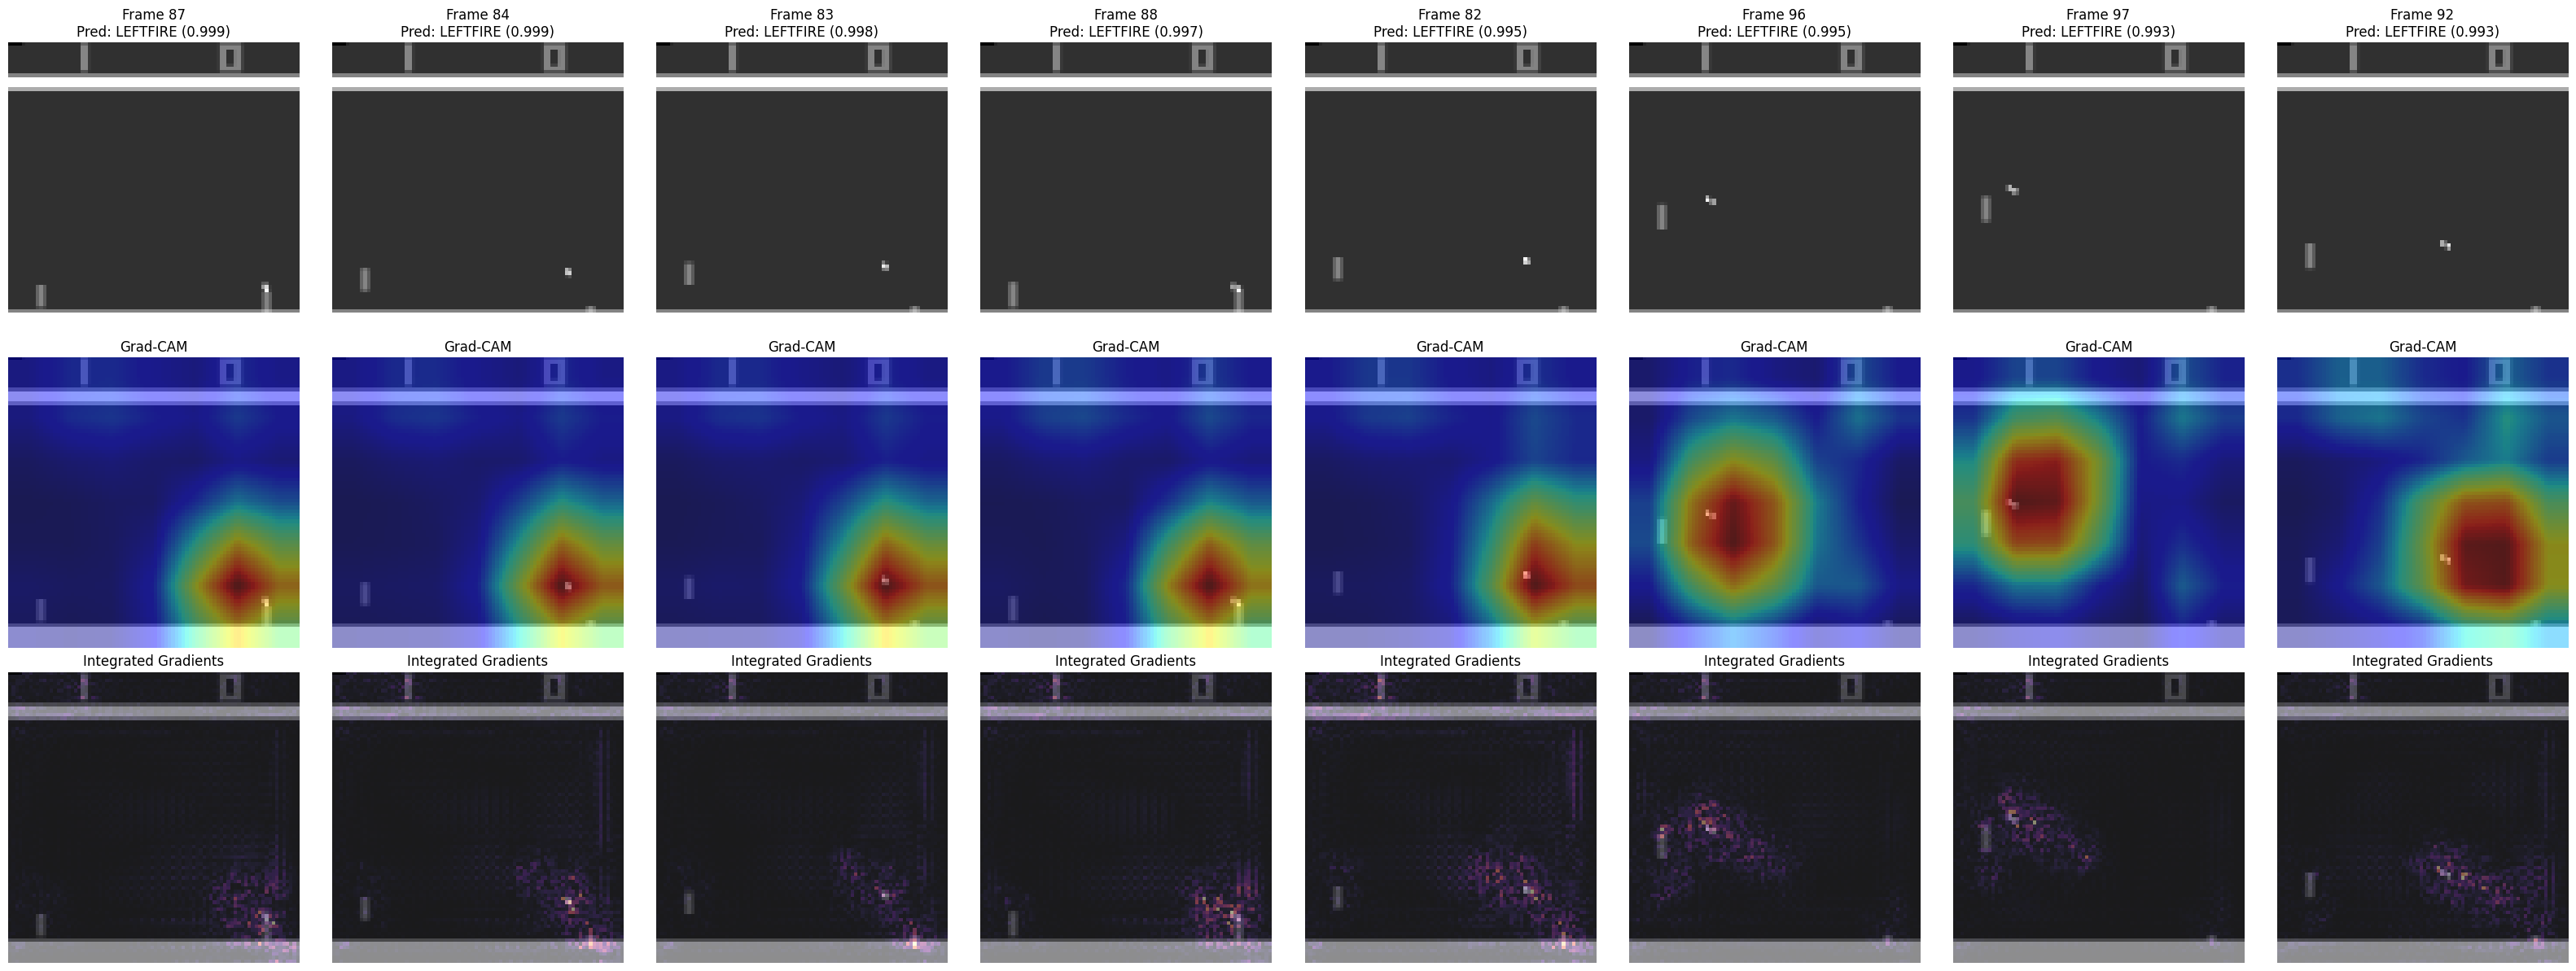

In [18]:
show_xai_examples(
    agent=e4_agent,
    obs_bank=xai_obs,
    idx_list=top_indices[:8],
    action_labels=action_meanings,
    forced_actions=xai_actions,
    save_path="e4_gradcam_ig_examples.png"
)

  1000/5000
  2000/5000
  3000/5000
  4000/5000
  5000/5000
Dataset: (5000, 4, 84, 84)
Ball labels: (5000, 2)
Random baseline: 22.16 px

Extracting E4 policy features...
Policy features: (5000, 512)

Linear Probe: E4 Policy Features
  [E4 Policy] Epoch 25: train=58.64px | test=59.78px
  [E4 Policy] Epoch 50: train=45.39px | test=46.46px
  [E4 Policy] Epoch 75: train=35.50px | test=36.39px
  [E4 Policy] Epoch 100: train=29.19px | test=29.91px
  [E4 Policy] Final test error: 29.91px

Feature                    Dims      Error    vs Random
--------------------------------------------------------
Random baseline               -      22.16            -
E4 Policy features          512      29.91       -35.0%


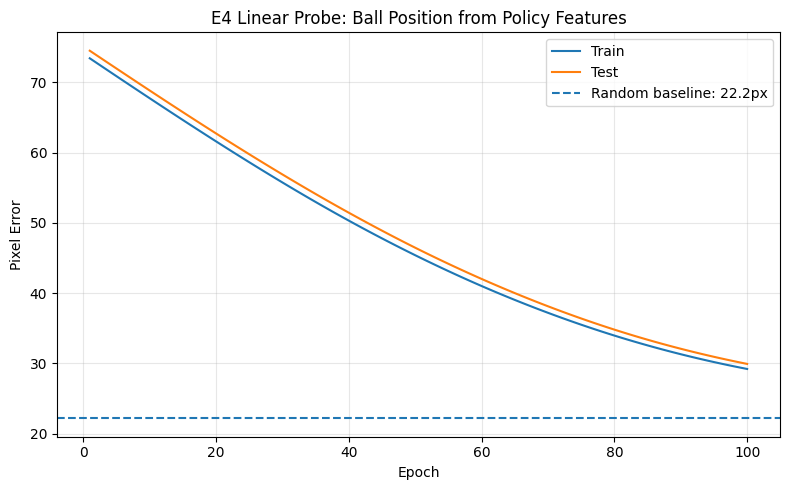

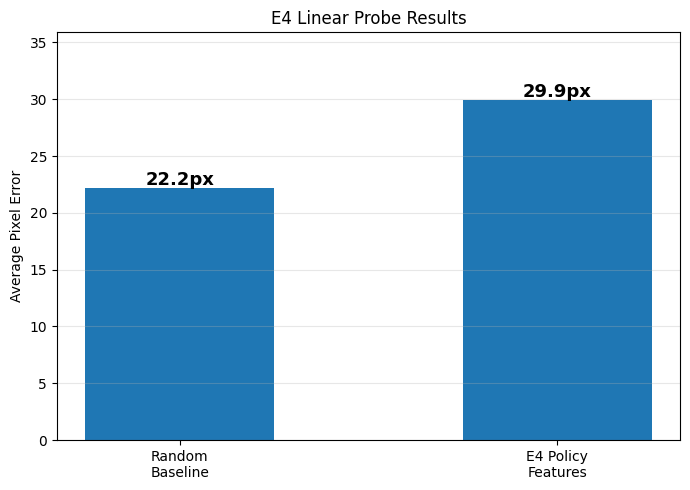

Saved:
 - e4_linear_probe_curve.png
 - e4_linear_probe_bar.png
 - e4_linear_probe_results.json
 - shared_obs_data_e4.npy
 - e4_features_policy.npy


In [20]:
# ======================================================================
# Linear Probe — E4 Ball Position Prediction
# Uses your already loaded e4_agent
# ======================================================================

from scipy import ndimage
from sklearn.model_selection import train_test_split
import json

def find_ball_position(frame):
    binary = (frame > 200).astype(np.uint8)
    labeled, n = ndimage.label(binary)

    if n == 0:
        return None

    best_pos, best_size = None, 999

    for lid in range(1, n + 1):
        ys, xs = np.where(labeled == lid)

        if len(ys) == 0:
            continue

        size = len(ys)
        height = ys.max() - ys.min() + 1
        width = xs.max() - xs.min() + 1

        # ball is small and roughly square
        if 1 <= size <= 12 and height <= 4 and width <= 4:
            if size < best_size:
                best_size = size
                best_pos = (float(ys.mean()), float(xs.mean()))

    return best_pos


print("Collecting probing dataset...")

probe_env = gym.make(args.env_id, frameskip=1, repeat_action_probability=0.0)
probe_env = gym.wrappers.AtariPreprocessing(
    probe_env,
    frame_skip=4,
    screen_size=84,
    terminal_on_life_loss=False,
    grayscale_obs=True,
    scale_obs=False,
)
probe_env = gym.wrappers.FrameStackObservation(probe_env, 4)

observations, positions = [], []
obs_p, _ = probe_env.reset(seed=args.seed + 5000)

target_samples = 5000
collected = 0

while collected < target_samples:
    obs_p, _, terminated, truncated, _ = probe_env.step(probe_env.action_space.sample())

    if terminated or truncated:
        obs_p, _ = probe_env.reset()
        continue

    obs_np = np.asarray(obs_p)

    if obs_np.shape[0] == 4:
        latest_frame = obs_np[-1]
    else:
        latest_frame = obs_np[..., -1]

    pos = find_ball_position(latest_frame)

    if pos is not None:
        observations.append(obs_np)
        positions.append(pos)
        collected += 1

        if collected % 1000 == 0:
            print(f"  {collected}/{target_samples}")

probe_env.close()

obs_data = np.asarray(observations, dtype=np.uint8)
ball_data = np.asarray(positions, dtype=np.float32)

print("Dataset:", obs_data.shape)
print("Ball labels:", ball_data.shape)


# ----------------------------
# Baseline
# ----------------------------
mean_pos = ball_data.mean(axis=0)
random_baseline = np.sqrt(((ball_data - mean_pos) ** 2).sum(axis=1)).mean()
print(f"Random baseline: {random_baseline:.2f} px")


# ----------------------------
# Extract E4 features
# ----------------------------
print("\nExtracting E4 policy features...")

e4_agent.eval()
feats_policy = []

with torch.no_grad():
    for i in range(0, len(obs_data), 128):
        batch = torch.as_tensor(
            obs_data[i:i + 128],
            dtype=torch.uint8,
            device=args.device
        )

        # E4 representation: ResNet-18 encoder + projector
        feat = e4_agent.get_features(batch)
        feats_policy.append(feat.cpu())

feats_policy = torch.cat(feats_policy).numpy()

print("Policy features:", feats_policy.shape)


# ----------------------------
# Train linear probe
# ----------------------------
def train_probe(features, targets, name, epochs=100, lr=1e-3):
    X_tr, X_te, y_tr, y_te = train_test_split(
        features,
        targets,
        test_size=0.2,
        random_state=42
    )

    X_tr = torch.as_tensor(X_tr, dtype=torch.float32, device=args.device)
    X_te = torch.as_tensor(X_te, dtype=torch.float32, device=args.device)
    y_tr = torch.as_tensor(y_tr, dtype=torch.float32, device=args.device)
    y_te = torch.as_tensor(y_te, dtype=torch.float32, device=args.device)

    probe = nn.Linear(features.shape[1], 2).to(args.device)
    opt = torch.optim.Adam(probe.parameters(), lr=lr)

    train_errs = []
    test_errs = []

    for epoch in range(epochs):
        probe.train()

        pred = probe(X_tr)
        loss = F.mse_loss(pred, y_tr)

        opt.zero_grad()
        loss.backward()
        opt.step()

        probe.eval()
        with torch.no_grad():
            train_err = torch.sqrt(((probe(X_tr) - y_tr) ** 2).sum(1)).mean().item()
            test_err = torch.sqrt(((probe(X_te) - y_te) ** 2).sum(1)).mean().item()

        train_errs.append(train_err)
        test_errs.append(test_err)

        if (epoch + 1) % 25 == 0:
            print(f"  [{name}] Epoch {epoch + 1}: train={train_err:.2f}px | test={test_err:.2f}px")

    print(f"  [{name}] Final test error: {test_errs[-1]:.2f}px")
    return test_errs[-1], train_errs, test_errs


print(f"\n{'=' * 68}")
print("Linear Probe: E4 Policy Features")
print(f"{'=' * 68}")

err_policy, curve_train, curve_test = train_probe(
    feats_policy,
    ball_data,
    "E4 Policy"
)

improvement = (1 - err_policy / random_baseline) * 100

print(f"\n{'=' * 68}")
print(f"{'Feature':<22} {'Dims':>8} {'Error':>10} {'vs Random':>12}")
print(f"{'-' * 56}")
print(f"{'Random baseline':<22} {'-':>8} {random_baseline:>10.2f} {'-':>12}")
print(f"{'E4 Policy features':<22} {feats_policy.shape[1]:>8} {err_policy:>10.2f} {improvement:>11.1f}%")
print(f"{'=' * 68}")


# ----------------------------
# Plot learning curve
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(1, len(curve_train) + 1), curve_train, label="Train")
ax.plot(range(1, len(curve_test) + 1), curve_test, label="Test")
ax.axhline(random_baseline, linestyle="--", label=f"Random baseline: {random_baseline:.1f}px")

ax.set_xlabel("Epoch")
ax.set_ylabel("Pixel Error")
ax.set_title("E4 Linear Probe: Ball Position from Policy Features")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("e4_linear_probe_curve.png", dpi=200, bbox_inches="tight")
plt.show()


# ----------------------------
# Plot bar chart
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

names = ["Random\nBaseline", "E4 Policy\nFeatures"]
vals = [random_baseline, err_policy]

bars = ax.bar(names, vals, width=0.5)

for b, v in zip(bars, vals):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.3,
        f"{v:.1f}px",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

ax.set_ylabel("Average Pixel Error")
ax.set_title("E4 Linear Probe Results")
ax.set_ylim(0, max(vals) * 1.2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("e4_linear_probe_bar.png", dpi=200, bbox_inches="tight")
plt.show()


# ----------------------------
# Save results
# ----------------------------
probe_results = {
    "random_baseline": float(random_baseline),
    "policy": {
        "dims": int(feats_policy.shape[1]),
        "error": float(err_policy),
        "improvement_percent": float(improvement),
    },
}

with open("e4_linear_probe_results.json", "w") as f:
    json.dump(probe_results, f, indent=2)

np.save("shared_obs_data_e4.npy", obs_data)
np.save("e4_features_policy.npy", feats_policy)

print("Saved:")
print(" - e4_linear_probe_curve.png")
print(" - e4_linear_probe_bar.png")
print(" - e4_linear_probe_results.json")
print(" - shared_obs_data_e4.npy")
print(" - e4_features_policy.npy")

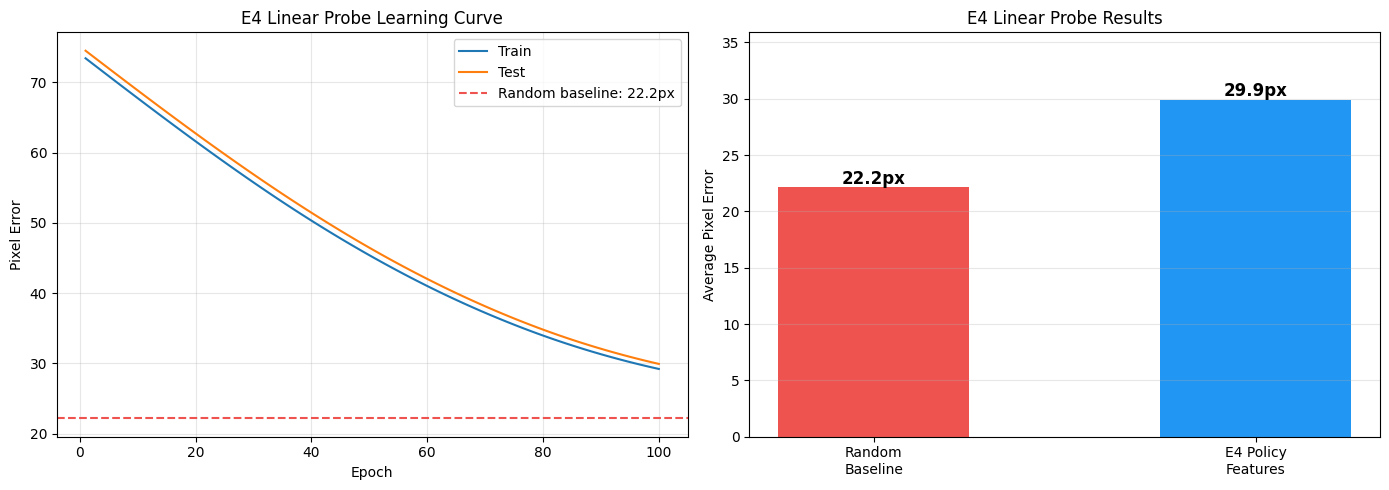

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: learning curve
axes[0].plot(range(1, len(curve_train) + 1), curve_train, label="Train")
axes[0].plot(range(1, len(curve_test) + 1), curve_test, label="Test")
axes[0].axhline(random_baseline, linestyle="--", color="#EF5350",
                label=f"Random baseline: {random_baseline:.1f}px")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Pixel Error")
axes[0].set_title("E4 Linear Probe Learning Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: bar chart
names = ["Random\nBaseline", "E4 Policy\nFeatures"]
vals = [random_baseline, err_policy]
colors = ["#EF5350", "#2196F3"]

bars = axes[1].bar(names, vals, color=colors, width=0.5)

for b, v in zip(bars, vals):
    axes[1].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.3,
        f"{v:.1f}px",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

axes[1].set_ylabel("Average Pixel Error")
axes[1].set_title("E4 Linear Probe Results")
axes[1].set_ylim(0, max(vals) * 1.2)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("e4_linear_probe_combined.png", dpi=200, bbox_inches="tight")
plt.show()